# 03. Playlist characteristics → Top 1% concentration

2차까지 확정된 것:

- MPD는 강한 Long-tail
- Top 1% ratio는 플리마다 크게 다름 (P10≈20%, P90≈97%)
- Length만으로는 그 차이를 설명하기 어렵다 (평균 차 ~4%p, 짧은 플리의 분산만 큼)

이번 질문:

> **왜 어떤 Playlist는 Top 1% 인기곡 중심이고, 어떤 Playlist는 아닌가?**

순서 (한꺼번에 상관행렬을 깔지 않음):

1. `num_followers`
2. 관계가 보이면 **Length 통제**
3. `num_edits`
4. 전체에서 패턴이 보이면, 마지막에 `num_tracks >= 20` sensitivity

메인 지표: `top_1pct_ratio`. 연속형(`avg_log_n_playlists`)은 보조.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

HERE = Path.cwd()
if (HERE / "data" / "processed").exists():
    ROOT = HERE
elif (HERE.parent / "data" / "processed").exists():
    ROOT = HERE.parent
else:
    ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

Y = "top_1pct_ratio"
MIN_TRACKS_SENS = 20

In [2]:
comp = pd.read_parquet(PROCESSED / "playlist_composition.parquet")
meta = pd.read_parquet(
    PROCESSED / "playlist_meta.parquet",
    columns=["pid", "num_tracks", "num_followers", "num_edits", "num_artists"],
)
df = comp.merge(meta, on="pid", how="inner")
df["log_followers"] = np.log1p(df["num_followers"])
df["log_edits"] = np.log1p(df["num_edits"])

print(f"n={len(df):,}")
print(df[["num_followers", "num_edits", "num_tracks", Y]].describe().round(3))

n=1,000,000
       num_followers    num_edits   num_tracks  top_1pct_ratio
count    1000000.000  1000000.000  1000000.000     1000000.000
mean           2.598       17.656       66.346           0.672
std          128.851       20.643       53.669           0.287
min            1.000        1.000        5.000           0.000
25%            1.000        5.000       26.000           0.489
50%            1.000       10.000       49.000           0.759
75%            1.000       22.000       92.000           0.909
max        71643.000      201.000      376.000           1.000


In [3]:
def describe_y(s: pd.Series) -> pd.Series:
    s = s.dropna()
    return pd.Series({
        "n": len(s),
        "mean": s.mean(),
        "p50": s.median(),
        "p25": s.quantile(0.25),
        "p75": s.quantile(0.75),
        "iqr": s.quantile(0.75) - s.quantile(0.25),
        "p10": s.quantile(0.10),
        "p90": s.quantile(0.90),
    })


def bin_summary(frame: pd.DataFrame, bin_col: str) -> pd.DataFrame:
    out = frame.groupby(bin_col, observed=True)[Y].apply(describe_y).unstack()
    return out


def spearman(frame: pd.DataFrame, x: str) -> float:
    return frame[[x, Y]].dropna().corr(method="spearman").iloc[0, 1]

## A. `num_followers`

질문: **팔로워가 많은 Playlist일수록 Top 1% 비중이 높은가?**

MPD에서 followers는 극단적으로 치우쳐 있다 (대다수가 1). 그래서 상관계수 하나보다 **bin별 분포**를 본다.

In [4]:
print("followers value shares (top):")
print(df["num_followers"].value_counts(normalize=True).head(10).round(4))
print(f"\nSpearman(num_followers, {Y}) = {spearman(df, 'num_followers'):.4f}")
print(f"Spearman(log_followers, {Y}) = {spearman(df, 'log_followers'):.4f}")

followers value shares (top):
num_followers
1     0.7542
2     0.1496
3     0.0469
4     0.0196
5     0.0098
6     0.0054
7     0.0033
8     0.0021
9     0.0015
10    0.0010
Name: proportion, dtype: float64

Spearman(num_followers, top_1pct_ratio) = 0.0056
Spearman(log_followers, top_1pct_ratio) = 0.0056


In [5]:
follower_bins = [0, 1, 2, 5, 10, 50, np.inf]
follower_labels = ["1", "2", "3-5", "6-10", "11-50", "51+"]
df["follower_bin"] = pd.cut(
    df["num_followers"],
    bins=follower_bins,
    labels=follower_labels,
    right=True,
)

fol_stats = bin_summary(df, "follower_bin")
fol_stats.round(3)

,n,mean,p50,p25,p75,iqr,p10,p90
follower_bin,,,,,,,,
1,754219.0,0.670,0.756,0.486,0.909,0.423,0.200,0.976
2,149600.0,0.681,0.769,0.500,0.913,0.413,0.219,0.972
3-5,76343.0,0.680,0.769,0.500,0.915,0.415,0.216,0.971
6-10,13326.0,0.651,0.740,0.443,0.906,0.463,0.161,0.966
11-50,5209.0,0.596,0.667,0.356,0.870,0.514,0.096,0.959
51+,1303.0,0.534,0.574,0.250,0.830,0.580,0.035,0.938


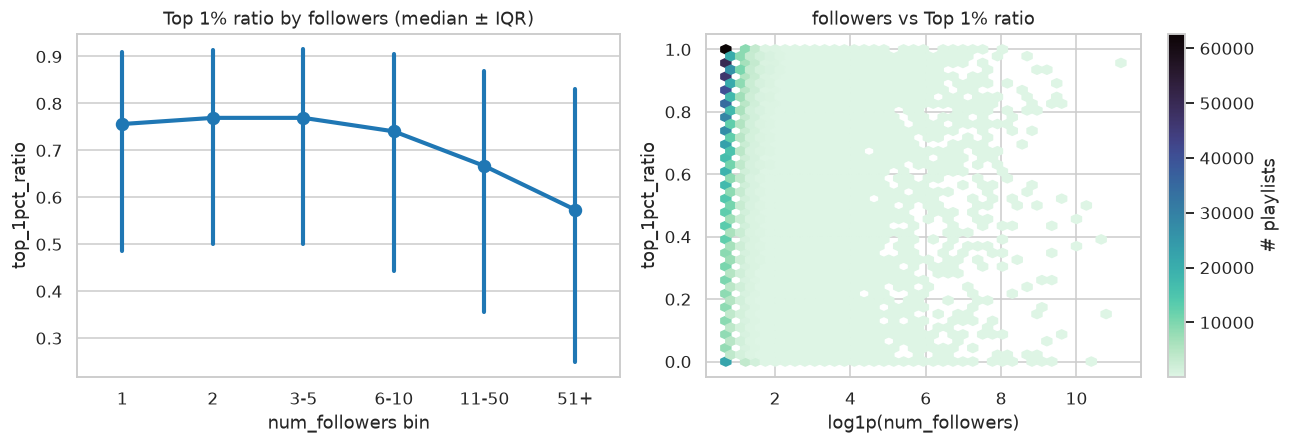

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.pointplot(
    data=df, x="follower_bin", y=Y,
    estimator="median", errorbar=("pi", 50),
    ax=axes[0], color="#1f77b4",
)
axes[0].set_title("Top 1% ratio by followers (median ± IQR)")
axes[0].set_xlabel("num_followers bin")
axes[0].set_ylabel("top_1pct_ratio")

hb = axes[1].hexbin(
    df["log_followers"], df[Y],
    gridsize=40, cmap="mako_r", mincnt=1,
)
axes[1].set_xlabel("log1p(num_followers)")
axes[1].set_ylabel("top_1pct_ratio")
axes[1].set_title("followers vs Top 1% ratio")
fig.colorbar(hb, ax=axes[1], label="# playlists")
fig.tight_layout()

**여기서 판단:** bin 평균/중앙값이 한 방향으로 의미 있게 움직이는가?

- 거의 평평하면 → Followers는 약한 설명 변수. Edits로 넘어간다.
- 기울기가 있으면 → Length 대리변수인지 통제한다.

## B. Followers 관계가 있을 때 — Length 통제

질문: **같은 길이 구간 안에서도 Followers와 Top 1% ratio 관계가 남는가?**

A에서 관계가 거의 없으면 이 칸은 “관계 없음 확인” 정도로만 보고 넘어가도 된다.

In [7]:
len_bins = [0, 20, 50, 100, 150, 400]
len_labels = ["1-20", "21-50", "51-100", "101-150", "151+"]
df["len_bin"] = pd.cut(df["num_tracks"], bins=len_bins, labels=len_labels, right=True)

# 각 길이 bin 안에서 followers bin별 median Top1
pivot = (
    df.groupby(["len_bin", "follower_bin"], observed=True)[Y]
    .median()
    .unstack("follower_bin")
)
pivot.round(3)

follower_bin,1,2,3-5,6-10,11-50,51+
len_bin,,,,,,
1-20,0.750,0.727,0.667,0.545,0.562,0.500
21-50,0.771,0.778,0.758,0.683,0.564,0.579
51-100,0.768,0.784,0.793,0.758,0.652,0.589
101-150,0.744,0.772,0.784,0.774,0.719,0.613
151+,0.706,0.741,0.763,0.766,0.739,0.628


,len_bin,n,spearman_followers
0,1-20,178744,-0.0342
1,21-50,333702,-0.0076
2,51-100,271072,0.0216
3,101-150,120954,0.0470
4,151+,95528,0.0719


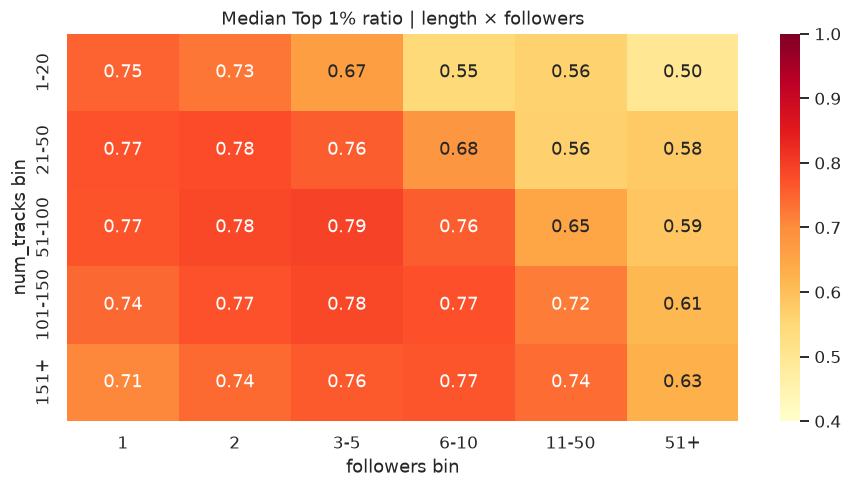

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, vmin=0.4, vmax=1.0)
ax.set_title("Median Top 1% ratio | length × followers")
ax.set_xlabel("followers bin")
ax.set_ylabel("num_tracks bin")
fig.tight_layout()

# 길이 bin별 Spearman(followers, Top1)
rows = []
for lab, g in df.groupby("len_bin", observed=True):
    rows.append({"len_bin": lab, "n": len(g), "spearman_followers": spearman(g, "num_followers")})
pd.DataFrame(rows).round(4)

## C. `num_edits`

질문: **많이 수정된 Playlist일수록 Top 1% concentration이 달라지는가?**

가능 가설 예:
- edits↑ → Top1↓ (오래 관리되며 다양해짐)
- edits↑ → Top1↑ (반복 편집이 인기곡 쪽으로)

결과 방향을 보고 다음 해석을 연다.

In [9]:
print(f"Spearman(num_edits, {Y}) = {spearman(df, 'num_edits'):.4f}")
print(f"Spearman(log_edits, {Y}) = {spearman(df, 'log_edits'):.4f}")

df["edit_bin"] = pd.qcut(df["num_edits"], q=5, duplicates="drop")
edit_stats = bin_summary(df, "edit_bin")
edit_stats.round(3)

Spearman(num_edits, top_1pct_ratio) = -0.0221
Spearman(log_edits, top_1pct_ratio) = -0.0221


,n,mean,p50,p25,p75,iqr,p10,p90
edit_bin,,,,,,,,
"(0.999, 4.0]",246056.0,0.652,0.750,0.417,0.929,0.512,0.118,1.000
"(4.0, 7.0]",161923.0,0.675,0.775,0.478,0.927,0.449,0.167,1.000
"(7.0, 13.0]",192444.0,0.680,0.771,0.500,0.917,0.417,0.211,0.974
"(13.0, 27.0]",204820.0,0.682,0.762,0.517,0.903,0.386,0.250,0.963
"(27.0, 201.0]",194757.0,0.674,0.741,0.520,0.879,0.359,0.286,0.944


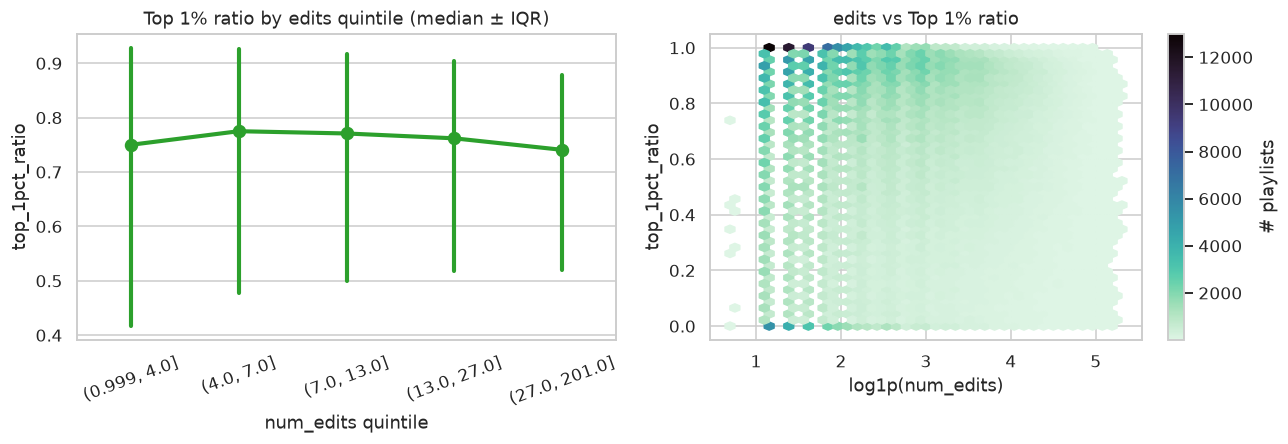

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.pointplot(
    data=df, x="edit_bin", y=Y,
    estimator="median", errorbar=("pi", 50),
    ax=axes[0], color="#2ca02c",
)
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_title("Top 1% ratio by edits quintile (median ± IQR)")
axes[0].set_xlabel("num_edits quintile")
axes[0].set_ylabel("top_1pct_ratio")

hb = axes[1].hexbin(
    df["log_edits"], df[Y],
    gridsize=40, cmap="mako_r", mincnt=1,
)
axes[1].set_xlabel("log1p(num_edits)")
axes[1].set_ylabel("top_1pct_ratio")
axes[1].set_title("edits vs Top 1% ratio")
fig.colorbar(hb, ax=axes[1], label="# playlists")
fig.tight_layout()

### C-2. Edits도 Length(필요하면 Followers) 통제

Edits↔Length 상관이 클 수 있으니, 길이 bin 안에서 edits 효과가 남는지 본다.

In [11]:
print(f"Spearman(num_edits, num_tracks) = {df[['num_edits','num_tracks']].corr(method='spearman').iloc[0,1]:.4f}")
print(f"Spearman(num_edits, num_followers) = {df[['num_edits','num_followers']].corr(method='spearman').iloc[0,1]:.4f}")

edit_by_len = (
    df.groupby(["len_bin", "edit_bin"], observed=True)[Y]
    .median()
    .unstack("edit_bin")
)
edit_by_len.round(3)

Spearman(num_edits, num_tracks) = 0.5675
Spearman(num_edits, num_followers) = 0.1912


edit_bin,"(0.999, 4.0]","(4.0, 7.0]","(7.0, 13.0]","(13.0, 27.0]","(27.0, 201.0]"
len_bin,,,,,
1-20,0.750,0.737,0.714,0.684,NaN
21-50,0.775,0.796,0.780,0.744,0.700
51-100,0.761,0.798,0.800,0.783,0.739
101-150,0.685,0.754,0.765,0.778,0.750
151+,0.536,0.658,0.685,0.735,0.741


,len_bin,n,spearman_edits
0,1-20,178744,-0.0293
1,21-50,333702,-0.0450
2,51-100,271072,-0.0449
3,101-150,120954,0.0028
4,151+,95528,0.0846


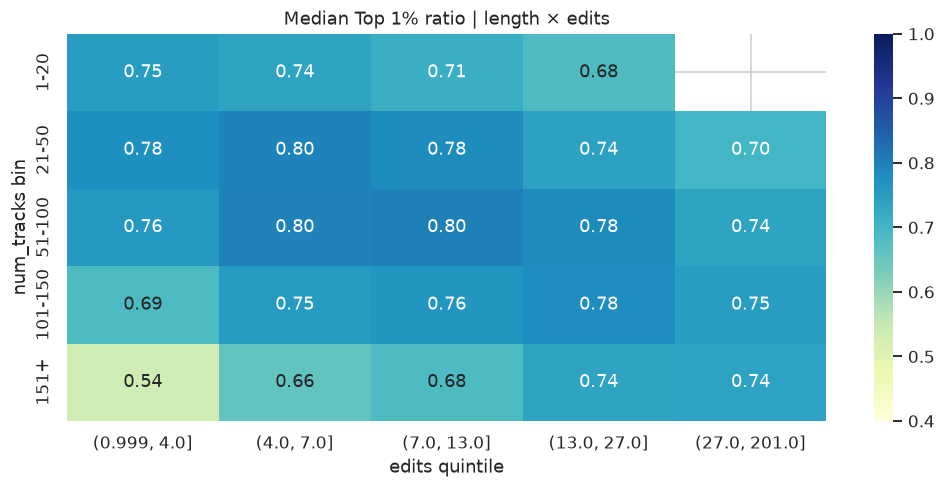

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
sns.heatmap(edit_by_len, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax, vmin=0.4, vmax=1.0)
ax.set_title("Median Top 1% ratio | length × edits")
ax.set_xlabel("edits quintile")
ax.set_ylabel("num_tracks bin")
fig.tight_layout()

rows = []
for lab, g in df.groupby("len_bin", observed=True):
    rows.append({"len_bin": lab, "n": len(g), "spearman_edits": spearman(g, "num_edits")})
pd.DataFrame(rows).round(4)

## D. Sensitivity — 짧은 Playlist 제외 (`num_tracks >= 20`)

짧은 플리에서는 곡 1개가 ratio를 크게 흔든다. **전체에서 본 패턴이 짧은 플리 아티팩트인지** 확인한다.

처음부터 제거하지 않는다. A–C 결과를 본 뒤, 같은 분석을 `num_tracks >= 20`에 다시 적용한다.

In [13]:
df_long = df[df["num_tracks"] >= MIN_TRACKS_SENS].copy()
print(f"all={len(df):,}  |  num_tracks>={MIN_TRACKS_SENS}: {len(df_long):,}  "
      f"({len(df_long)/len(df):.1%} kept)")

df_long["follower_bin"] = pd.cut(
    df_long["num_followers"], bins=follower_bins, labels=follower_labels, right=True,
)
df_long["edit_bin"] = pd.qcut(df_long["num_edits"], q=5, duplicates="drop")
df_long["len_bin"] = pd.cut(df_long["num_tracks"], bins=len_bins, labels=len_labels, right=True)

compare = pd.DataFrame({
    "all": {
        "spearman_followers": spearman(df, "num_followers"),
        "spearman_edits": spearman(df, "num_edits"),
        "top1_mean": df[Y].mean(),
        "top1_p50": df[Y].median(),
        "top1_p10": df[Y].quantile(0.10),
        "top1_p90": df[Y].quantile(0.90),
    },
    f">={MIN_TRACKS_SENS}": {
        "spearman_followers": spearman(df_long, "num_followers"),
        "spearman_edits": spearman(df_long, "num_edits"),
        "top1_mean": df_long[Y].mean(),
        "top1_p50": df_long[Y].median(),
        "top1_p10": df_long[Y].quantile(0.10),
        "top1_p90": df_long[Y].quantile(0.90),
    },
}).T
compare.round(4)

all=1,000,000  |  num_tracks>=20: 836,313  (83.6% kept)


,spearman_followers,spearman_edits,top1_mean,top1_p50,top1_p10,top1_p90
all,0.0056,-0.0221,0.6717,0.7586,0.2000,0.9744
>=20,0.0115,-0.0319,0.6760,0.7619,0.2167,0.9683


In [14]:
fol_all = bin_summary(df, "follower_bin")["p50"].rename("all")
fol_long = bin_summary(df_long, "follower_bin")["p50"].rename(f">={MIN_TRACKS_SENS}")
fol_cmp = pd.concat([fol_all, fol_long], axis=1)

# edit quintile labels differ between subsets — compare by order
edit_all = bin_summary(df, "edit_bin")["p50"].reset_index(drop=True)
edit_long = bin_summary(df_long, "edit_bin")["p50"].reset_index(drop=True)
edit_cmp = pd.DataFrame({"all": edit_all, f">={MIN_TRACKS_SENS}": edit_long})
edit_cmp.index = [f"Q{i+1}" for i in edit_cmp.index]

print("Followers bin → median Top1")
print(fol_cmp.round(3))
print("\nEdits quintile → median Top1")
edit_cmp.round(3)

Followers bin → median Top1
                all   >=20
follower_bin              
1             0.756  0.759
2             0.769  0.773
3-5           0.769  0.776
6-10          0.740  0.750
11-50         0.667  0.674
51+           0.574  0.588

Edits quintile → median Top1


,all,>=20
Q1,0.750,0.761
Q2,0.775,0.788
Q3,0.771,0.772
Q4,0.762,0.759
Q5,0.741,0.739


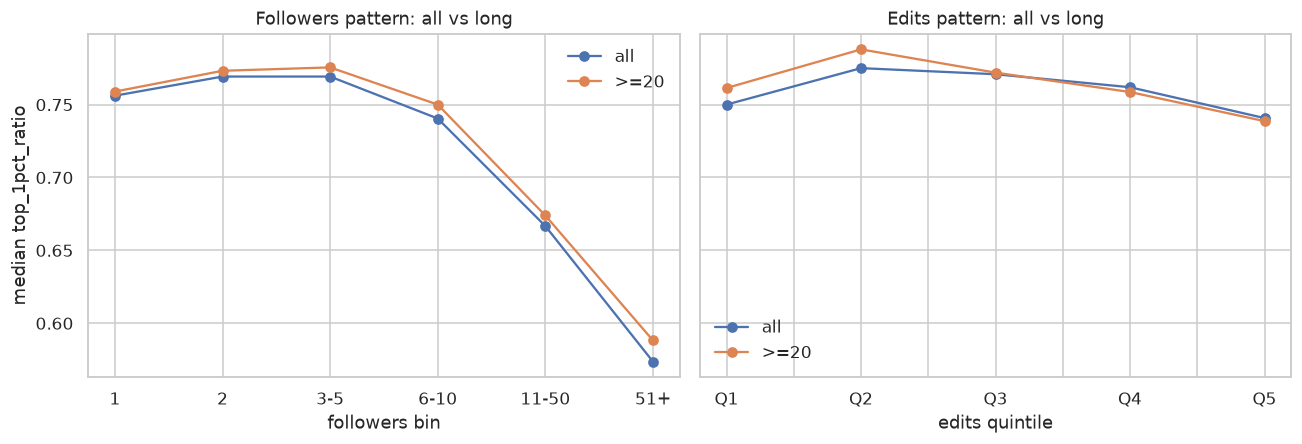

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

fol_cmp.plot(marker="o", ax=axes[0])
axes[0].set_title("Followers pattern: all vs long")
axes[0].set_xlabel("followers bin")
axes[0].set_ylabel("median top_1pct_ratio")
axes[0].legend(frameon=False)

edit_cmp.plot(marker="o", ax=axes[1])
axes[1].set_title("Edits pattern: all vs long")
axes[1].set_xlabel("edits quintile")
axes[1].legend(frameon=False)

fig.tight_layout()

## 이 노트북에서 결정할 것

| 결과 | 다음 |
|---|---|
| Followers/Edits가 Top1 차이를 상당 부분 설명 + long subset에서도 유지 | 그 특성을 추천 실험 설계에 연결 |
| 관계는 있으나 Length 통제 후 사라짐 | 해당 변수는 대리변수. Diversity 쪽으로 |
| 둘 다 약하고, long subset에서도 Top1 P10–P90이 넓음 | **Artist diversity / repetition**으로 “구성 자체가 다른가?” |
| long subset에서만 패턴이 사라짐 | 짧은 플리 아티팩트 가능성. 이후 분석은 `num_tracks>=20` 기준을 기본으로 |

Title은 아직 강제하지 않는다. Diversity·추천 단계에서 필요할 때만.